# Adverse selection in passive market making

**nanolob — phase 5.** This notebook quantifies *adverse selection*: the tendency of a passive
quote to get filled precisely when the market is about to move against the position it creates.
A market maker's fill is not a random sample of time — it is a sample conditioned on someone
aggressive choosing to trade with you, and that someone is disproportionately informed (or at
least momentum-aligned).

Inputs are the CSVs written by `nanolob_mmsim` over the same Binance BTCUSDT capture:

- `results/{as,naive}_timeseries.csv` — one row per 100 ms book update (mid, vol, inventory, PnL decomposition, live quotes)
- `results/{as,naive}_fills.csv` — one row per simulated fill (price, qty, mid at fill, queue wait)

`as` = Avellaneda–Stoikov with inventory penalty; `naive` = fixed symmetric spread with the same
size, inventory cap, and clamping. Units: prices in ticks (0.01 USDT), quantities in lots (1e-5 BTC).

**Caveats before believing anything below**: one capture session, one symbol, simulated fills with
a prorated queue model, no fees, no latency. The *methodology* is the deliverable; the numbers are
one sample from it.

Two data-pipeline bugs were found and fixed while building this analysis, both worth knowing about
because they are easy to reproduce in any exchange-data project:

1. **CSV precision.** The exported mid was written with `ostream`'s default 6 *significant* digits,
   which quantized a ~6.4e6-tick price onto a 10-tick grid and erased every sub-0.10-USDT move.
   The simulation itself was always full-precision — only the export was lossy.
2. **Mixed clocks.** Fills were timestamped with Binance's trade time `T` while book updates used
   the capture host's local wall clock, which was measured ~1.44 s behind the exchange. Every
   fill-relative horizon below was silently skewed by that amount. Both series now use the
   exchange event clock (`E`), which moved the 1 s markout from -526 to -417 ticks.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS = Path("../results")
TICK = 0.01  # USDT

def load(prefix):
    # Sort both frames by time: merge_asof requires sorted keys and returns a
    # fresh RangeIndex, so an unsorted left frame silently misaligns results.
    ts = pd.read_csv(RESULTS / f"{prefix}_timeseries.csv").sort_values("ts_ms").reset_index(drop=True)
    fills = pd.read_csv(RESULTS / f"{prefix}_fills.csv").sort_values("ts_ms").reset_index(drop=True)
    ts["mid"] = ts["mid_ticks"]
    fills["mid_at_fill"] = fills["mid2_at_fill"] / 2.0
    # +1 if the fill made us longer (we bought on our bid), -1 if shorter.
    fills["dir"] = np.where(fills["side"] == "B", 1.0, -1.0)
    return ts, fills

as_ts, as_fills = load("as")
nv_ts, nv_fills = load("naive")

session_min = (as_ts.ts_ms.iloc[-1] - as_ts.ts_ms.iloc[0]) / 60000
print(f"session: {session_min:.1f} minutes, {len(as_ts)} book updates")
print(f"fills: A-S {len(as_fills)}, naive {len(nv_fills)}")

session: 25.0 minutes, 14968 book updates
fills: A-S 529, naive 183


## 1. Markouts: what happens to the mid *after* we get filled

The markout at horizon $\Delta$ is the signed mid move after a fill:

$$\text{markout}(\Delta) = d \cdot (m_{t+\Delta} - m_t), \qquad d = +1 \text{ for buys}, -1 \text{ for sells}$$

If fills were uninformed, this curve would hover near zero. Adverse selection shows up as a
**negative, decaying curve** — the mid drifts away from the side we just took. We also plot the
*realized edge*, $d\cdot(m_{t+\Delta} - p_{\text{fill}})$: what the fill is actually worth after
the market has had $\Delta$ seconds to react (edge at fill + markout).

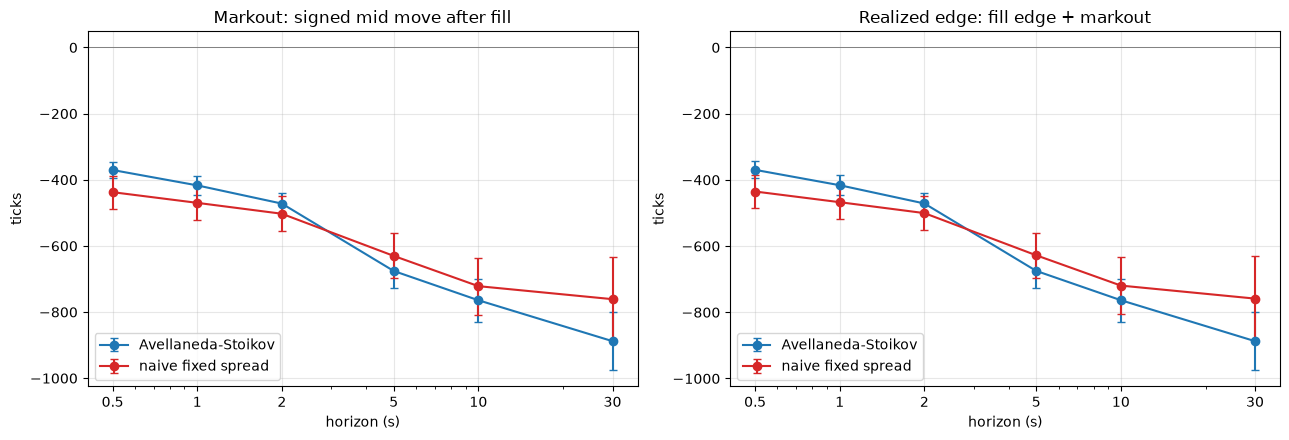

A-S: edge at fill +0.79 ticks, markout 5s -675.79, realized 5s -675.00, realized 30s -887.22
naive: edge at fill +2.40 ticks, markout 5s -630.22, realized 5s -627.82, realized 30s -758.63


In [2]:
HORIZONS_S = [0.5, 1, 2, 5, 10, 30]

def markouts(fills, ts):
    mids = ts[["ts_ms", "mid"]].sort_values("ts_ms")
    out = fills.copy()
    for h in HORIZONS_S:
        probe = fills[["ts_ms"]].copy()
        probe["ts_ms"] = probe["ts_ms"] + int(h * 1000)
        merged = pd.merge_asof(probe, mids, on="ts_ms", direction="backward")
        out[f"mid_{h}s"] = merged["mid"].values
        out[f"markout_{h}s"] = out["dir"] * (out[f"mid_{h}s"] - out["mid_at_fill"])
        out[f"realized_{h}s"] = out["edge_ticks"] + out[f"markout_{h}s"]
    return out

as_mk = markouts(as_fills, as_ts)
nv_mk = markouts(nv_fills, nv_ts)

def curve(mk, col_prefix):
    mean = [mk[f"{col_prefix}_{h}s"].mean() for h in HORIZONS_S]
    se = [mk[f"{col_prefix}_{h}s"].std() / np.sqrt(len(mk)) for h in HORIZONS_S]
    return np.array(mean), np.array(se)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for mk, name, color in [(as_mk, "Avellaneda-Stoikov", "#1f77b4"),
                        (nv_mk, "naive fixed spread", "#d62728")]:
    m, se = curve(mk, "markout")
    ax1.errorbar(HORIZONS_S, m, yerr=2 * se, marker="o", capsize=3, label=name, color=color)
    r, se_r = curve(mk, "realized")
    ax2.errorbar(HORIZONS_S, r, yerr=2 * se_r, marker="o", capsize=3, label=name, color=color)
for ax, title in [(ax1, "Markout: signed mid move after fill"),
                  (ax2, "Realized edge: fill edge + markout")]:
    ax.axhline(0, color="gray", lw=0.7)
    ax.set_xscale("log"); ax.set_xticks(HORIZONS_S); ax.set_xticklabels(HORIZONS_S)
    ax.set_xlabel("horizon (s)"); ax.set_ylabel("ticks"); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

for name, mk in [("A-S", as_mk), ("naive", nv_mk)]:
    print(f"{name}: edge at fill {mk.edge_ticks.mean():+.2f} ticks, "
          f"markout 5s {mk.markout_5s.mean():+.2f}, realized 5s {mk.realized_5s.mean():+.2f}, "
          f"realized 30s {mk.realized_30s.mean():+.2f}")

A downward-sloping markout curve is the fingerprint of adverse selection: on average the mid
moves *away* from whatever we just accumulated, and the few ticks of edge captured at the fill are
eaten (or worse) within seconds. Compare the two strategies: A-S trades more often (it requotes
toward its reservation price and sheds inventory), so its per-fill markout tends to be less
extreme, while the naive quoter sits still and gets picked off by larger moves.

## 2. Fill rate vs subsequent midprice move

The complementary view: instead of asking *"what happens after fills?"*, classify every 100 ms
step by whether one of our quotes was filled within the next second, and compare the distribution
of the **subsequent 5 s mid move** for filled vs unfilled steps — signed so that positive =
favorable to the position the fill would create. If getting filled carried no information, the two
distributions would match.

Avellaneda-Stoikov: mean 5s move | not filled +20.85 ticks, | filled -530.42 ticks  (gap = -551.27)
naive fixed spread: mean 5s move | not filled +17.89 ticks, | filled -577.96 ticks  (gap = -595.85)


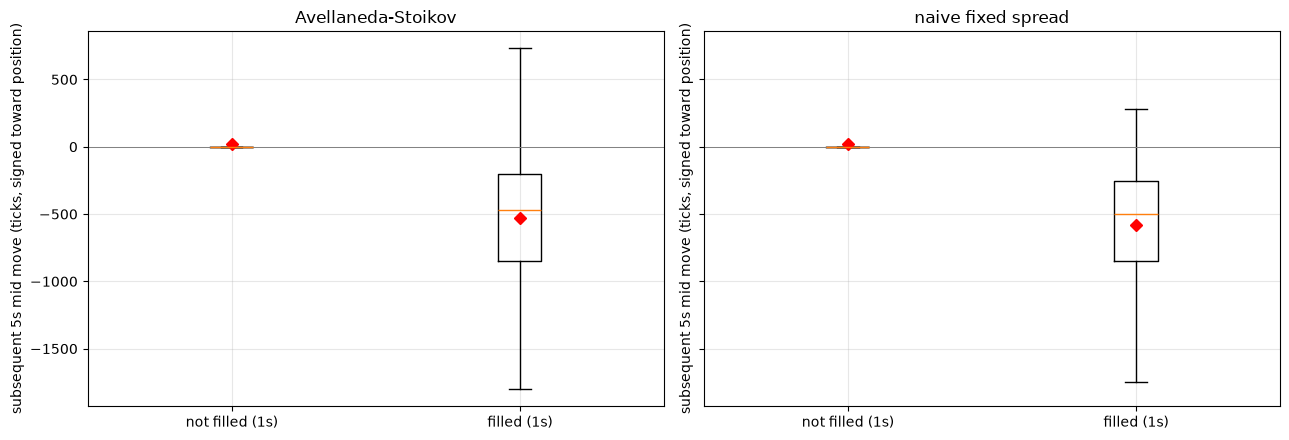

In [3]:
def fill_conditional_moves(ts, fills, look_ms=1000, horizon_ms=5000):
    mids = ts[["ts_ms", "mid"]].sort_values("ts_ms")
    probe = ts[["ts_ms"]].copy(); probe["ts_ms"] += horizon_ms
    fwd = pd.merge_asof(probe, mids, on="ts_ms", direction="backward")["mid"].values
    move = fwd - ts["mid"].values  # unsigned forward move

    rows = []
    for side, d in [("B", 1.0), ("S", -1.0)]:
        f_ts = np.sort(fills.loc[fills["side"] == side, "ts_ms"].values)
        if len(f_ts) == 0:
            continue
        nxt = np.searchsorted(f_ts, ts["ts_ms"].values)
        has_fill = (nxt < len(f_ts)) & (f_ts[np.minimum(nxt, len(f_ts) - 1)]
                                        <= ts["ts_ms"].values + look_ms)
        rows.append(pd.DataFrame({"signed_move": d * move, "filled": has_fill}))
    return pd.concat(rows, ignore_index=True).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
summary = {}
for ax, (name, ts, fills) in zip(axes, [("Avellaneda-Stoikov", as_ts, as_fills),
                                        ("naive fixed spread", nv_ts, nv_fills)]):
    cm = fill_conditional_moves(ts, fills)
    groups = [cm.loc[~cm.filled, "signed_move"], cm.loc[cm.filled, "signed_move"]]
    ax.boxplot(groups, tick_labels=["not filled (1s)", "filled (1s)"], showfliers=False)
    for i, g in enumerate(groups, 1):
        ax.plot(i, g.mean(), "D", color="red", ms=6)
    ax.axhline(0, color="gray", lw=0.7)
    ax.set_title(name); ax.set_ylabel("subsequent 5s mid move (ticks, signed toward position)")
    ax.grid(alpha=0.3)
    summary[name] = (g_mean_unf := groups[0].mean(), g_mean_f := groups[1].mean())
    print(f"{name}: mean 5s move | not filled {groups[0].mean():+.2f} ticks, "
          f"| filled {groups[1].mean():+.2f} ticks  "
          f"(gap = {groups[1].mean() - groups[0].mean():+.2f})")
plt.tight_layout(); plt.show()

The gap between the two red diamonds *is* adverse selection, in ticks: conditional on being
filled in the next second, the following five seconds move systematically against the position the
fill creates. Note this is measured against each strategy's own quoting behavior — A-S skews away
from its inventory, so it is sometimes filled on mean-reverting flow it *wanted* (shedding), which
shrinks the gap.

## 3. Where the PnL actually went

In [4]:
def summarize(name, ts, fills, mk):
    quoting = ((ts.bid_px > 0) & (ts.ask_px > 0)).mean()
    return {
        "strategy": name,
        "fills": len(fills),
        "traded (BTC)": (fills.qty_lots.sum() * 1e-5).round(4),
        "avg edge @fill (ticks)": round(mk.edge_ticks.mean(), 2),
        "avg realized @5s (ticks)": round(mk.realized_5s.mean(), 2),
        "avg realized @30s (ticks)": round(mk.realized_30s.mean(), 2),
        "median queue wait (s)": round(fills.queue_wait_ms.median() / 1000, 1),
        "spread PnL (USDT)": round(ts.spread_pnl_usdt.iloc[-1], 4),
        "inventory PnL (USDT)": round(ts.inv_pnl_usdt.iloc[-1], 4),
        "total PnL (USDT)": round(ts.pnl_usdt.iloc[-1], 4),
        "max |inventory| (BTC)": round(ts.inventory_lots.abs().max() * 1e-5, 3),
        "% time two-sided": f"{quoting:.0%}",
    }

table = pd.DataFrame([summarize("Avellaneda-Stoikov", as_ts, as_fills, as_mk),
                      summarize("naive fixed spread", nv_ts, nv_fills, nv_mk)]).set_index("strategy")
table

,fills,traded (BTC),avg edge @fill (ticks),avg realized @5s (ticks),avg realized @30s (ticks),median queue wait (s),spread PnL (USDT),inventory PnL (USDT),total PnL (USDT),max |inventory| (BTC),% time two-sided
strategy,,,,,,,,,,,
Avellaneda-Stoikov,529,3.0378,0.79,-675.00,-887.22,4.2,-0.0136,-23.5724,-23.5860,0.136,47%
naive fixed spread,183,2.6800,2.40,-627.82,-758.63,2.5,0.0482,-23.5556,-23.5074,0.120,37%


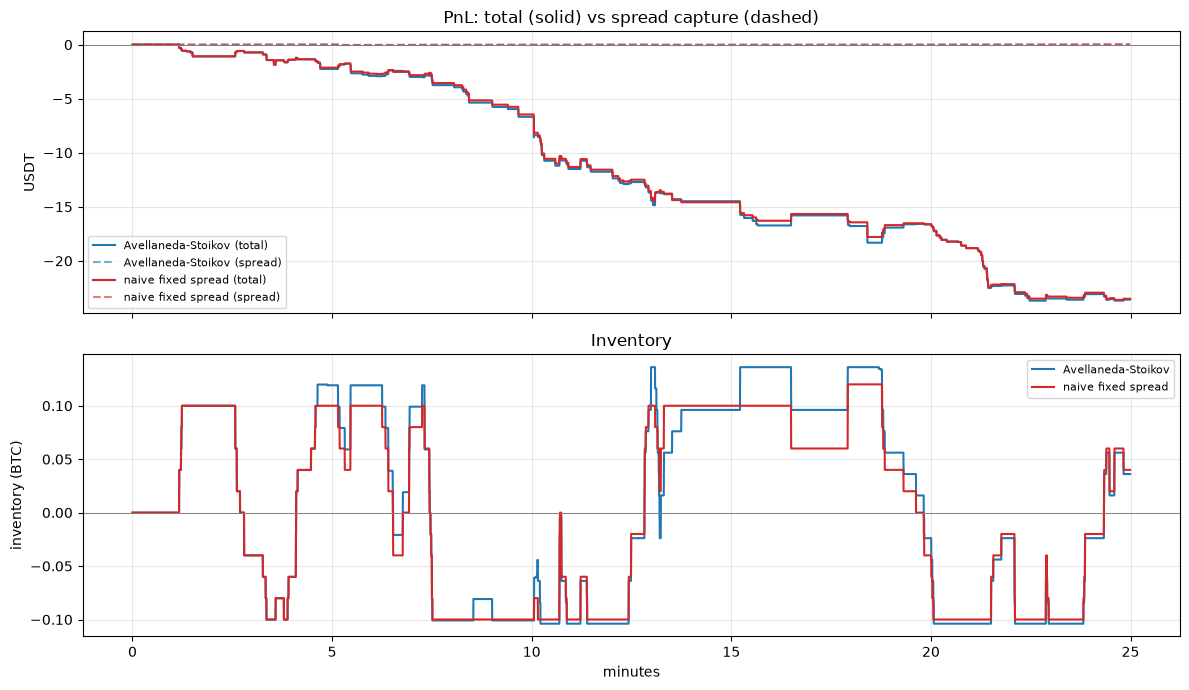

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
t0 = as_ts.ts_ms.iloc[0]
for ts, name, color in [(as_ts, "Avellaneda-Stoikov", "#1f77b4"),
                        (nv_ts, "naive fixed spread", "#d62728")]:
    t = (ts.ts_ms - t0) / 60000
    ax1.plot(t, ts.pnl_usdt, color=color, label=f"{name} (total)")
    ax1.plot(t, ts.spread_pnl_usdt, color=color, ls="--", alpha=0.6, label=f"{name} (spread)")
    ax2.plot(t, ts.inventory_lots * 1e-5, color=color, label=name)
ax1.axhline(0, color="gray", lw=0.7); ax1.set_ylabel("USDT")
ax1.set_title("PnL: total (solid) vs spread capture (dashed)"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.axhline(0, color="gray", lw=0.7); ax2.set_ylabel("inventory (BTC)"); ax2.set_xlabel("minutes")
ax2.set_title("Inventory"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Reading the results honestly

- **Spread capture is pennies; inventory is dollars.** The captured session *rallied* ~104 USDT
  (64095 -> 64199). Both strategies were repeatedly lifted on their offers (A-S: 296 sells vs 233
  buys), leaving them short into the rise — so a few cents of spread capture sat next to ~23 USDT
  of inventory loss. This is *the* lesson of passive market making: the quoting policy's real job
  is inventory control, not spread capture.
- **A-S vs naive.** A-S fills far more often (it chases its reservation price), keeps inventory
  closer to zero on average, and its markout per fill is milder — but on a one-directional session
  neither strategy's inventory management can rescue headline PnL. The difference shows up in the
  *paths* (inventory plot) and in the conditional-move gap, not necessarily in one session's final
  PnL number.
- **What's missing before any of this resembles production:** maker fees/rebates (which dwarf 1-2
  tick edges), latency between signal and quote update, queue-position uncertainty (our proration
  is a neutral guess), self-impact (our fills would have changed the book), and more than one
  session of data across regimes.
- **Next experiments this framework supports cheaply:** sweep gamma/tau to trace the inventory-vs-
  spread frontier, calibrate k from the trade stream instead of fixing it, add a fee model, and
  run captures across quiet vs volatile hours.